text - 1차시
전처리 => 소문자 변환 / 토큰화 / 불용어 제거
정수 인코딩 => 단어 사전 구축 및 정수 인코딩

In [1]:
import os
import re
import pandas as pd
import pickle
from collections import Counter

In [2]:
# 불용어
stop_words = {
    # 대명사
    "i", "me", "my", "myself", "we", "our", "ourselves", 
    "you", "your", "yours", "yourself", "he", "him", "his", 
    "she", "her", "it", "its", "they", "them", "themselves",
    # be동사 / 조동사
    "is", "am", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "do", "does", "did",
    "will", "would", "shall", "should", "can", "could",
    # 관사 / 전치사
    "a", "an", "the",
    "in", "on", "at", "to", "for", "of", "with", "by", "from",
    # 접속사 (but 제외)
    "and", "or", "if", "then",
    # 기타
    "this", "that", "these", "those",
    "there", "here", "what", "which", "who",
    "all", "each", "some", "any",
    "about", "up", "out",
}


In [3]:
#감정 단어 정의
emotion_words = {
    # positive
    "good", "great", "awesome", "amazing", "excellent", "fantastic",
    "wonderful", "nice", "love", "loved", "like", "liked",
    "fun", "funny", "cool", "best", "favorite", "enjoy", "enjoyed",
    "beautiful", "perfect", "strong", "interesting",

    # negative
    "bad", "terrible", "awful", "horrible", "worst", "boring",
    "hate", "hated", "dislike", "ugly", "annoying", "disappointing",
    "disappointed", "poor", "weak", "stupid", "dumb", "ridiculous",
    "unfunny", "mess", "waste",
    # direct emotion
    "happy", "sad", "angry", "upset", "excited", "depressed",
    "frustrated", "surprised", "shocked", "scared", "afraid",
    "emotional"
}

In [4]:
# 데이터 샘플 확인
data_path = r"C:\Users\wanje\Desktop\deeplearning\Raw\mosi_text_metadata.csv"
df = pd.read_csv(data_path)

print(f"데이터 수: {len(df)}")
print(f"\n샘플 확인:")
print(df[["text"]].head(5))

데이터 수: 2199

샘플 확인:
                                                text
0                          ANYHOW IT WAS REALLY GOOD
1  THAY DID THEY DIDNT REALLY DO A WHOLE BUNCH OF...
2                 I MEAN THEY DID A LITTLE BIT OF IT
3                              BUT NOT A WHOLE BUNCH
4                          AND THEY SHOULDVE I GUESS


In [5]:
# 텍ㅅ트에 데이터 전처리 적용 => 1차시 40p
def preprocess_text(text, remove_emotion_words=False):
    text = text.lower() # 소문자 변환
    text = re.sub(r'[^\w\s]', '', text) # 특수문자 제거
    tokens = text.split() # 토큰화 
    tokens = [token for token in tokens if token not in stop_words] # 불용어 제거
    
    # 감정 단어 제거
    if remove_emotion_words:
        tokens = [tok for tok in tokens if tok not in emotion_words]
    return tokens

# 감정 단어 제거 전처리
df["tokens_no_emotion"] = df["text"].apply(lambda x: preprocess_text(x, True))

print("전처리 전후 비교:")
for i in range(3):
    print(f"  원본:  {df['text'].iloc[i]}")
    print(f"감정 제거: {df['tokens_no_emotion'].iloc[i]}")
    print()

전처리 전후 비교:
  원본:  ANYHOW IT WAS REALLY GOOD
감정 제거: ['anyhow', 'really']

  원본:  THAY DID THEY DIDNT REALLY DO A WHOLE BUNCH OF BACKGROUND INFO ON WHY SHE HAS TO FIGHT AND BE PREPARED
감정 제거: ['thay', 'didnt', 'really', 'whole', 'bunch', 'background', 'info', 'why', 'fight', 'prepared']

  원본:  I MEAN THEY DID A LITTLE BIT OF IT
감정 제거: ['mean', 'little', 'bit']



In [6]:
# 감정 단어 제거 버전 정수 인코딩
all_tokens_no_emotion = []
for tokens in df["tokens_no_emotion"]:
    for token in tokens:
        all_tokens_no_emotion.append(token)
word_counts_no_emotion = Counter(all_tokens_no_emotion)

print(f"전체 고유 단어 수 (감정 단어 제거): {len(word_counts_no_emotion)}")
print(f"가장 많이 등장한 단어 10개 (감정 단어 제거): {word_counts_no_emotion.most_common(10)}")

MIN_FREQ = 1 # 본래 값: 2 -> 1 로 수정
# 거의 모든 단어를 살린다 : 잡음 多, 정보를 가장 많이 살리는 방향
vocab_no_emotion = {"<PAD>": 0, "<UNK>": 1}
idx = 2
for word, count in word_counts_no_emotion.items():
    if count >= MIN_FREQ:
        vocab_no_emotion[word] = idx
        idx += 1
print(f"vocab_no_emotion 크기 (감정 단어 제거): {len(vocab_no_emotion)}")

전체 고유 단어 수 (감정 단어 제거): 2981
가장 많이 등장한 단어 10개 (감정 단어 제거): [('um', 421), ('movie', 407), ('really', 369), ('but', 354), ('just', 280), ('so', 204), ('know', 203), ('not', 169), ('think', 128), ('one', 124)]
vocab_no_emotion 크기 (감정 단어 제거): 2983


In [7]:
# 정수 인코딩 함수: 단어 사전(VOCAB)에서 각 단어의 번호를 찾아온다.
def encode_tokens(tokens, vocab_no_emotion):
    encoded = []
    for word in tokens:
        if word in vocab_no_emotion:
            # 토큰 리스트를 받아서 각 단어를 VOCAB에서 찾아 번호를 바꾼다.
            encoded.append(vocab_no_emotion[word])
        else:
            encoded.append(vocab_no_emotion["<UNK>"])
    return encoded

# 감정 단어 제거 버전 정수 인코딩
encoded_list_no_emotion = []
for t in df["tokens_no_emotion"]:
    encoded_list_no_emotion.append(encode_tokens(t, vocab_no_emotion))
df["encoded_no_emotion"] = encoded_list_no_emotion

In [8]:
save_dir = r"C:\Users\wanje\Desktop\deeplearning"

# 감정 제거 인코딩 결과 저장
save_data_no_emotion = {
    "encoded": df["encoded_no_emotion"].tolist(),
    "labels": df["label"].values,
    "video_ids": df["video_id"].values,
    "vocab": vocab_no_emotion,
    "texts": df["text"].values,
}
# 감정 제거 인코딩 결과 파일 저장``
save_path_no_emotion = os.path.join(save_dir, "text_preprocessed_data_no_emotion.pkl")
with open(save_path_no_emotion, "wb") as f:
    pickle.dump(save_data_no_emotion, f)

print(f"저장 완료: {save_path_no_emotion}")
print(f"  데이터 수: {len(save_data_no_emotion['encoded'])}")
print(f"  vocab_no_emotion 크기: {len(vocab_no_emotion)}")

저장 완료: C:\Users\wanje\Desktop\deeplearning\text_preprocessed_data_no_emotion.pkl
  데이터 수: 2199
  vocab_no_emotion 크기: 2983


2차시 => 패딩(길이통일) + 임베딩(숫자->벡터)

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModel

c:\Users\wanje\anaconda3\envs\main\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


저장한 전처리 + 정수 인코딩 결과 불러오기

In [10]:
save_dir2 = r"C:\Users\wanje\Desktop\deeplearning\text_preprocessed_data_no_emotion.pkl"
with open(save_dir2, "rb") as last_file:
    text_data2 = pickle.load(last_file)

# 패딩: 가장 긴 문장 길이 맞추기
max_len = 0
for seq in text_data2["encoded"]:
    if len(seq) > max_len:
        max_len = len(seq)

padded_max = []
for seq in text_data2["encoded"]:
    pad_count = max_len - len(seq)
    padded_max.append(seq + [vocab_no_emotion["<PAD>"]] * pad_count)

# 고정 길이로 맞추기
fixed_len = 10
padded_fixed2 = []
for seq in text_data2["encoded"]:
    fixed_seq = seq[:fixed_len]  # 고정 길이로 자르기
    pad_count = fixed_len - len(fixed_seq)  # 패딩할 개수
    padded_fixed2.append(fixed_seq + [vocab_no_emotion["<PAD>"]] * pad_count)
text_data2["padded_fixed2"] = padded_fixed2

print("0번째 문장:", text_data2["texts"][0])
print("정수 인코딩 결과:", text_data2["encoded"][0])
print("고정 길이 패딩:", text_data2["padded_fixed2"][0])

0번째 문장: ANYHOW IT WAS REALLY GOOD
정수 인코딩 결과: [2, 3]
고정 길이 패딩: [2, 3, 0, 0, 0, 0, 0, 0, 0, 0]


임베딩: 단어 의미를 벡터로 표햔하기 위한 과정

In [11]:
embedding_dim = 4

embedding_table = torch.randn(len(vocab_no_emotion), embedding_dim)
embedding_table[vocab_no_emotion["<PAD>"]] = 0

print("임베딩 테이블 shape:", embedding_table.shape)
print("PAD 벡터:", embedding_table[vocab_no_emotion["<PAD>"]])

임베딩 테이블 shape: torch.Size([2983, 4])
PAD 벡터: tensor([0., 0., 0., 0.])


In [12]:
# 임베딩: 단어의 의미를 벡터로 표현하기 위한 과정
# Embedding 구현 
sample_seq1 = padded_fixed2[0] 

sentence_vectors = []

for token_idx in sample_seq1:
    token_vector = embedding_table[token_idx]
    sentence_vectors.append(token_vector)

sentence_vectors = torch.stack(sentence_vectors)

print("0번째 문장:", text_data2["texts"][0])
print("0번째 문장 정수 인코딩:", sample_seq1)
print("문장 길이:", len(sample_seq1))
print("\n0번째 문장의 임베딩 결과 shape:", sentence_vectors.shape)
print("0번째 문장의 임베딩 결과:", (sentence_vectors))


# nn.Embedding 활용
X = torch.tensor(padded_fixed2, dtype=torch.long)
y = torch.tensor(text_data2["labels"], dtype=torch.long)

embedding_layer = nn.Embedding(
    num_embeddings=len(vocab_no_emotion),
    embedding_dim=4,
    padding_idx=vocab_no_emotion["<PAD>"]
)

embedded_text = embedding_layer(X)
print("\nnn.Embedding 결과 shape:", embedded_text.shape)
print("첫 번째 문장 임베딩 결과:")
print(embedded_text[0])

0번째 문장: ANYHOW IT WAS REALLY GOOD
0번째 문장 정수 인코딩: [2, 3, 0, 0, 0, 0, 0, 0, 0, 0]
문장 길이: 10

0번째 문장의 임베딩 결과 shape: torch.Size([10, 4])
0번째 문장의 임베딩 결과: tensor([[-1.7461,  0.3199,  0.8247, -0.3415],
        [ 1.4780, -2.6912,  0.5380, -0.3449],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

nn.Embedding 결과 shape: torch.Size([2199, 10, 4])
첫 번째 문장 임베딩 결과:
tensor([[-0.8788, -0.3932, -0.9076,  0.4283],
        [ 0.9506,  2.4412, -2.1127,  0.6775],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
  

In [13]:
# 사전학습 모델 활용
model_name = "google-bert/bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

sentence = text_data2["texts"][0]

inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
embeddings = outputs.last_hidden_state[0]

print("문장:", sentence)

for token, emb in zip(tokens, embeddings):
    print(f"토큰: {token}")
    print(f"벡터 앞 5개 값: {emb[:5].tolist()}")
    print()

문장: ANYHOW IT WAS REALLY GOOD
토큰: [CLS]
벡터 앞 5개 값: [0.27537861466407776, 0.5214540958404541, 0.15492990612983704, -0.03061075508594513, -0.21965113282203674]

토큰: AN
벡터 앞 5개 값: [-1.043573021888733, -0.1528216451406479, 0.19757944345474243, 0.7298051118850708, 0.1045314371585846]

토큰: ##Y
벡터 앞 5개 값: [-0.3096957802772522, -0.12426143139600754, -0.18246303498744965, 0.6591668128967285, 0.26444560289382935]

토큰: ##H
벡터 앞 5개 값: [-0.4722752273082733, 0.995591402053833, -0.027917858213186264, 0.7027592658996582, -0.22906605899333954]

토큰: ##OW
벡터 앞 5개 값: [0.13739891350269318, 0.23970404267311096, -0.14093263447284698, 0.1297909915447235, 0.26485317945480347]

토큰: IT
벡터 앞 5개 값: [-0.3721908628940582, 0.19955213367938995, 0.02042205259203911, 0.9711361527442932, 0.15533792972564697]

토큰: WA
벡터 앞 5개 값: [-0.8836513161659241, 0.33360767364501953, -0.0933530256152153, 0.9428226947784424, 0.11695477366447449]

토큰: ##S
벡터 앞 5개 값: [-0.19380132853984833, 0.23485338687896729, 0.38944777846336365, 0.83773

In [14]:
# ── 1) 데이터 준비 ──
import os, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data_path = r"C:\Users\wanje\Desktop\deeplearning\text_preprocessed_data_no_emotion.pkl"
with open(data_path, "rb") as f:
    data = pickle.load(f)

encoded = data["encoded"]
labels  = data["labels"]
vocab   = data["vocab"]

MAX_LEN = 70 # 본래 값: 50 -> 70 : 문맥 보존을 더 살리기 위해 파리미터값 변경
PAD_IDX = vocab["<PAD>"]

def pad_sequence(seq, max_len, pad_idx):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))


X_padded = np.array([pad_sequence(seq, MAX_LEN, PAD_IDX) for seq in encoded])
y        = labels.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

train_loader = DataLoader(TensorDataset(
    torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.long)), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(
    torch.tensor(X_test, dtype=torch.long), torch.tensor(y_test, dtype=torch.long)), batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device} | vocab: {len(vocab)} | train: {len(X_train)} | test: {len(X_test)}")

device: cpu | vocab: 2983 | train: 1759 | test: 440


In [15]:
# ── 2) 모델 정의 + 학습 ──
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,num_layers=1,nclass=2,pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, nclass)

    def forward(self, x):
        emb = self.embedding(x)
        output, h_n = self.rnn(emb)
        h_pool = torch.mean(output, dim=1)
        return self.fc(h_pool)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,num_layers=1,nclass=2,pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, nclass)

    def forward(self, x):
        emb = self.embedding(x)
        output, (h_n, c_n) = self.lstm(emb)
        h_pool = torch.mean(output, dim=1)
        return self.fc(h_pool)

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,num_layers=1,nclass=2,pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, nclass)

    def forward(self, x):
        emb = self.embedding(x)
        output, h_n = self.gru(emb)
        h_pool = torch.mean(output, dim=1)
        return self.fc(h_pool)

# 성능 지표 계산 함수
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score 
def eval_metrics(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=1)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred) # 정확도 계산
    precision = precision_score(y_true, y_pred, average='weighted') # 정밀도 계산
    recall = recall_score(y_true, y_pred, average='weighted') # 재현율 계산
    f1 = f1_score(y_true, y_pred, average='weighted') # F1 점수 계산
    return accuracy, precision, recall, f1

models = {
    "RNN":  RNNModel(vocab_size=len(vocab), embed_dim=64, hidden_dim=128),
    "LSTM": LSTMModel(vocab_size=len(vocab), embed_dim=64, hidden_dim=128),
    "GRU":  GRUModel(vocab_size=len(vocab), embed_dim=64, hidden_dim=128),
}
all_results = {}

for tag, model in models.items():
    model = model.to(device)
    opt  = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    # 손실 지표에 대한 확장 버전
    hist = {"loss": [], 
            "train_acc": [], "test_acc": [],
            "train_precision": [], "test_precision": [],
            "train_recall": [], "test_recall": [],
            "train_f1": [], "test_f1": []}

    print(f"\n{'='*40}  {tag}  {'='*40}")
    #학습 진행
    for epoch in range(1, 21):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        
        train_acc, train_precision, train_recall, train_f1 = eval_metrics(model, train_loader)
        test_acc, test_precision, test_recall, test_f1 = eval_metrics(model, test_loader)

        hist["loss"].append(epoch_loss)
        hist["train_acc"].append(train_acc)
        hist["test_acc"].append(test_acc)

        hist["train_precision"].append(train_precision)
        hist["test_precision"].append(test_precision)

        hist["train_recall"].append(train_recall)
        hist["test_recall"].append(test_recall)

        hist["train_f1"].append(train_f1)
        hist["test_f1"].append(test_f1)


        print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | "
              f"Train ACC: {train_acc:.4f} | Test ACC: {test_acc:.4f} | "
              f"Train Precision: {train_precision:.4f} | Test Precision: {test_precision:.4f} | "
              f"Train Recall: {train_recall:.4f} | Test Recall: {test_recall:.4f} | "
              f"Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")


    all_results[tag] = hist
    print(f"\n저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")


========================================  RNN  ========================================
Epoch 01 | Loss: 0.6926 | Train ACC: 0.4957 | Test ACC: 0.4795 | Train Precision: 0.7503 | Test Precision: 0.7510 | Train Recall: 0.4957 | Test Recall: 0.4795 | Train F1: 0.3299 | Test F1: 0.3134
Epoch 02 | Loss: 0.6916 | Train ACC: 0.5736 | Test ACC: 0.5455 | Train Precision: 0.6335 | Test Precision: 0.5523 | Train Recall: 0.5736 | Test Recall: 0.5455 | Train F1: 0.5152 | Test F1: 0.4920
Epoch 03 | Loss: 0.6745 | Train ACC: 0.5645 | Test ACC: 0.5114 | Train Precision: 0.7116 | Test Precision: 0.5975 | Train Recall: 0.5645 | Test Recall: 0.5114 | Train F1: 0.4772 | Test F1: 0.4143
Epoch 04 | Loss: 0.6551 | Train ACC: 0.5617 | Test ACC: 0.5455 | Train Precision: 0.6828 | Test Precision: 0.5938 | Train Recall: 0.5617 | Test Recall: 0.5455 | Train F1: 0.4698 | Test F1: 0.4417
Epoch 05 | Loss: 0.6267 | Train ACC: 0.7305 | Test ACC: 0.5773 | Train Precision: 0.7307 | Test Precision: 0.5769 | Train Recal

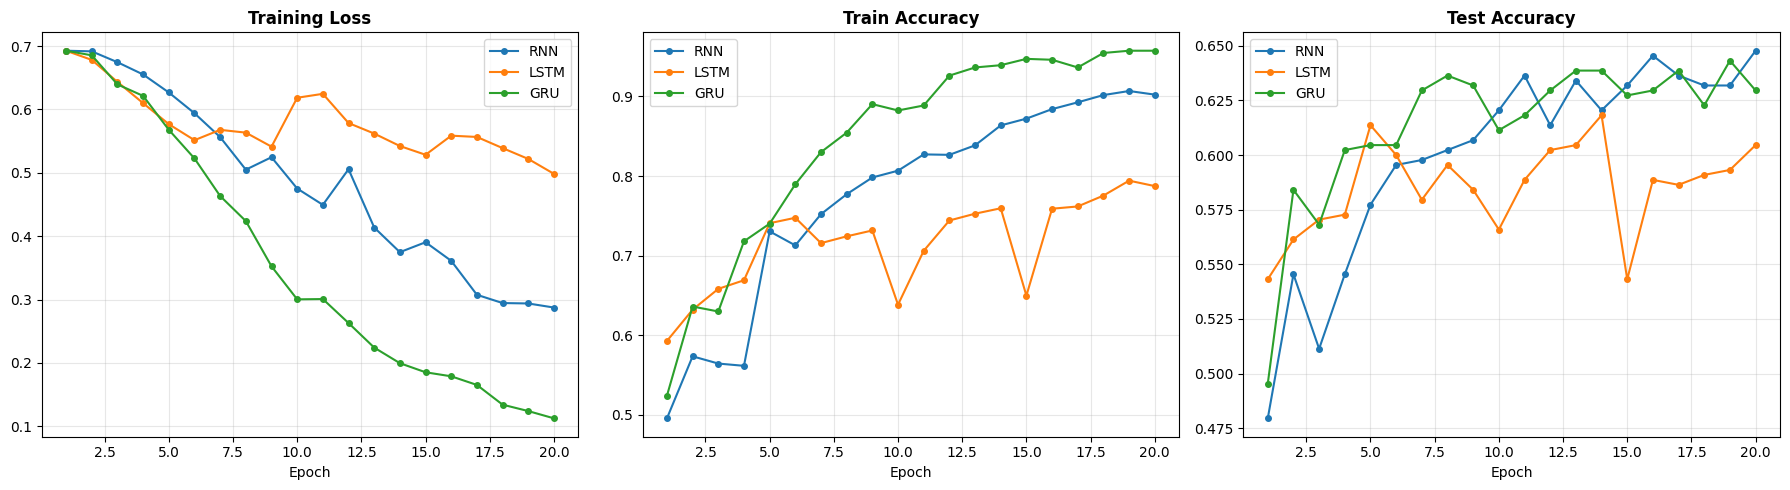


[최종 Test_no_emotion 성능 비교]
Test Accuracy: 0.6477 | Test Precision: 0.6567 |Test Recall: 0.6477 |Test F1: 0.6459
Test Accuracy: 0.6045 | Test Precision: 0.6104 |Test Recall: 0.6045 |Test F1: 0.6034
Test Accuracy: 0.6295 | Test Precision: 0.6350 |Test Recall: 0.6295 |Test F1: 0.6287


In [16]:
# ── 3) 시각화 ──
colors = {"RNN": "tab:blue", "LSTM": "tab:orange", "GRU": "tab:green"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for tag_name, res in all_results.items():
    c = colors.get(tag_name, "gray")
    ep = range(1, len(res["loss"]) + 1)
    axes[0].plot(ep, res["loss"],      color=c, marker="o", ms=4, label=tag_name)
    axes[1].plot(ep, res["train_acc"], color=c, marker="o", ms=4, label=tag_name)
    axes[2].plot(ep, res["test_acc"],  color=c, marker="o", ms=4, label=tag_name)
for ax, t in zip(axes, ["Training Loss", "Train Accuracy", "Test Accuracy"]):
    ax.set_title(t, fontweight="bold"); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\n[최종 Test_no_emotion 성능 비교]")
for tag_name, res in all_results.items():
    print(f"Test Accuracy: {res['test_acc'][-1]:.4f} | "
          f"Test Precision: {res['test_precision'][-1]:.4f} |"
          f"Test Recall: {res['test_recall'][-1]:.4f} |"
          f"Test F1: {res['test_f1'][-1]:.4f}")